In [1]:
import xarray as xr
import json
import pandas as pd
import torch
import numpy as np
from scipy.stats import gaussian_kde
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import os
import sys
sys.path.append('../')
import utils.evaluation as evaluation
import utils.utils as ut
import importlib

In [2]:
# load true test data
settings_file_path = "../../settings.json"
with open(settings_file_path, 'r') as file:
        settings = json.load(file)
no_epochs=settings['epochs']
standardization="train_stats"

### Factual ###
    
###########
### old ###
###########
### Load temperature TEST data ###
#ds_test_eth_fact_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_era5_transient'])
#ds_test_eth_fact_pre = xr.open_dataset(ds_test_eth_fact_path)


### load climatology ###
# load climatology
#era5_clim_pre = xr.open_dataset("/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/E5sf00_1D_T2M_1940-2025_remapped_to_CESM2_no_leap_clim.nc").var167
#era5_clim = era5_clim_pre.assign_coords(lon=((era5_clim_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))


# add climatology
#era5_clim_correct = np.transpose(np.tile(era5_clim.values, (84,1,1)), (2,1,0))
#ds_test_eth_fact = ds_test_eth_fact_pre + era5_clim_correct - 273.15
#print(ds_test_eth_fact)

###############
### current ###
###############

### Load temperature TEST data ###
ds_test_eth_fact_path_dummy = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_era5_transient'])
ds_test_eth_fact_pre_dummy = xr.open_dataset(ds_test_eth_fact_path_dummy)

# load CESM2 fact nudged to ERA5
ds_test_eth_fact_pre2 = xr.open_dataset("/work2/fl53wumy-fl53wumy-llaae_ws_new-1779067202/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/ERA5_factual_nudged_europe_10percent_masked_TREFHT_JJA.nc")
ds_test_eth_fact_pre = ds_test_eth_fact_pre2.assign_coords(lat=ds_test_eth_fact_pre_dummy.lat, lon=ds_test_eth_fact_pre_dummy.lon)

### load climatology ###
# load climatology
era5_clim_pre = xr.open_dataset("/work2/fl53wumy-fl53wumy-llaae_ws_new-1779067202/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/merged_TSA_fact_nudged_1940-2024_clim.nc").TSA #E5sf00_1D_T2M_1940-2025_remapped_to_CESM2_no_leap_clim.nc
era5_clim = era5_clim_pre.assign_coords(lon=((era5_clim_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_fact_pre.lat, lon=ds_test_eth_fact_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))


# add climatology
era5_clim_correct = np.transpose(np.tile(era5_clim.values, (84,1,1)), (0,1,2))
ds_test_eth_fact = ds_test_eth_fact_pre + era5_clim_correct - 273.15
print(ds_test_eth_fact)

# load DAE ensemble
# ADJUST FOLLOWING PATH IF NECESSARY

# current
#dae_ensemble_fact = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/ERA5_inherent_ensemble_after_50_epochs/ETH_gen_dpa_ens_50_dataset_restored.nc"
dae_ensemble_fact = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ERA5_{standardization}_ensemble_after_{no_epochs}_epochs/ETH_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)

# old generated ensemble, but good ?
#dae_eth_fact_path="/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_devicecpu100_6_100_100_1001_100_2_100_encoderislearnable_lambda1.0_alpha1.0_bs128_bnisTrue_lr5e-05_pene0/era5_test_set_reference_period_1950-1980_v5_dpa_train_settings_home_ERA5.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_gen_dpa_ens_50_dataset_restored.nc"

dae_eth_fact = xr.open_dataset(dae_eth_fact_path) + np.transpose(era5_clim_correct, (0,1,2)) - 273.15
dae_eth_fact


### Counterfactual ###

### Load counterfactual temperature TEST data ###
ds_test_eth_cf_path = os.path.join(settings['paths']['data'], settings['paths']['dataset_trefht_era5_nudged'])
ds_test_eth_cf_pre = xr.open_dataset(ds_test_eth_cf_path)

# load climatology
era5_nudged_clim_pre = xr.open_dataset("/work2/fl53wumy-fl53wumy-llaae_ws_new-1779067202/fl53wumy-llaae_ws_new-1779067202/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/other_data/merged_TREFHT_nudged_1940-2015_clim.nc").TREFHT
era5_nudged_clim = era5_nudged_clim_pre.assign_coords(lon=((era5_nudged_clim_pre.lon + 180) % 360) - 180).sortby("lon").sel(lat=ds_test_eth_cf_pre.lat, lon=ds_test_eth_cf_pre.lon).sel(time=slice("1980-06-02", "1980-08-31"))
era5_nudged_clim_correct = np.transpose(np.tile(era5_nudged_clim.values, (84,1,1)), (0,1,2))

# add climatology
ds_test_eth_cf = ds_test_eth_cf_pre + era5_nudged_clim_correct - 273.15#.rename({"var167": "TREFHT"})

# load DPA ensemble
# ADJUST FOLLOWING PATH IF NECESSARY

# current
dae_ensemble_cf = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ERA5_{standardization}_ensemble_after_{no_epochs}_epochs/ETH_cf_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)

dae_ensemble_cf_2028 = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ERA5_{standardization}_ensemble_after_{no_epochs}_epochs/ETH_cf_era5_2028_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_cf_path_2028 = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf_2028)

dae_ensemble_cf_2053 = f"{settings['current_model']}/dae_ensemble_after_{no_epochs}_epochs/ERA5_{standardization}_ensemble_after_{no_epochs}_epochs/ETH_cf_era5_2053_gen_dpa_ens_{no_epochs}_dataset_restored.nc"
dae_eth_cf_path_2053 = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf_2053)


# old generated ensemble, but good ?
#dae_eth_cf_path="/work2/fl53wumy-llaae_ws_new/fl53wumy-dpa_data/fl53wumy-llaae_data_new_22092025-1763346001/fl53wumy-llaae_data_new-1758244802/fl53wumy-llaae_data_new-1748049607/dpa_output/v5_model/_devicecpu100_6_100_100_1001_100_2_100_encoderislearnable_lambda1.0_alpha1.0_bs128_bnisTrue_lr5e-05_pene0/era5_test_set_reference_period_1950-1980_v5_dpa_train_settings_home_ERA5.json/dpa_ensemble_after_50_epochs/eth_ensemble_after_50_epochs/ETH_cf_gen_dpa_ens_50_dataset_restored.nc"

# need to add factual era5 anomalies as this is what model learns !!!
dae_eth_cf = xr.open_dataset(dae_eth_cf_path) +  np.transpose(era5_clim_correct,(0,1,2)) - 273.15#.rename({"var167": "TREFHT"})
dae_eth_cf_2028 = xr.open_dataset(dae_eth_cf_path_2028) +  np.transpose(era5_clim.values,(0,1,2)) - 273.15#.rename({"var167": "TREFHT"}) # add only one summer climatology
dae_eth_cf_2053 = xr.open_dataset(dae_eth_cf_path_2053) +  np.transpose(era5_clim.values,(0,1,2)) - 273.15#.rename({"var167": "TREFHT"}) # add only one summer climatology


# compute domain average temperature
weights = np.cos(np.deg2rad(dae_eth_fact.lat))
dae_eth_ens_spatial_mean = dae_eth_fact.TREFHT.weighted(weights).mean(dim=("lat","lon"))
weights = np.cos(np.deg2rad(dae_eth_cf.lat))
dae_eth_ens_spatial_mean_cf = dae_eth_cf.TREFHT.weighted(weights).mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf_2028 = dae_eth_cf_2028.TREFHT.weighted(weights).mean(dim=("lat","lon"))
dae_eth_ens_spatial_mean_cf_2053 = dae_eth_cf_2053.TREFHT.weighted(weights).mean(dim=("lat","lon"))

# compute ensemble 
# MEAN 
#fact_dae_mean = dae_eth_fact.mean(dim="ensemble_member")
#cf_dae_mean = dae_eth_cf.mean(dim="ensemble_member")
#cf_2028_dae_mean = dae_eth_cf_2028.mean(dim="ensemble_member")
#cf_2053_dae_mean = dae_eth_cf_2053.mean(dim="ensemble_member")

# or MEDIAN
fact_dae_mean = dae_eth_fact.median(dim="ensemble_member")
cf_dae_mean = dae_eth_cf.median(dim="ensemble_member")
cf_2028_dae_mean = dae_eth_cf_2028.median(dim="ensemble_member")
cf_2053_dae_mean = dae_eth_cf_2053.median(dim="ensemble_member")

##################
### set domain ###
##################
# FRANCE
fr_lat_min = 45
fr_lat_max = 50
fr_lon_min= 0
fr_lon_max= 5

<xarray.Dataset> Size: 7MB
Dimensions:  (time: 1596, lat: 32, lon: 32)
Coordinates:
  * time     (time) object 13kB 1940-06-02 00:00:00 ... 2023-08-31 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5
Data variables:
    TSA      (time, lat, lon) float32 7MB nan nan nan nan ... 15.5 15.46 15.59


## Explore ERA5 DAE ensemble

### Heatwave visualization

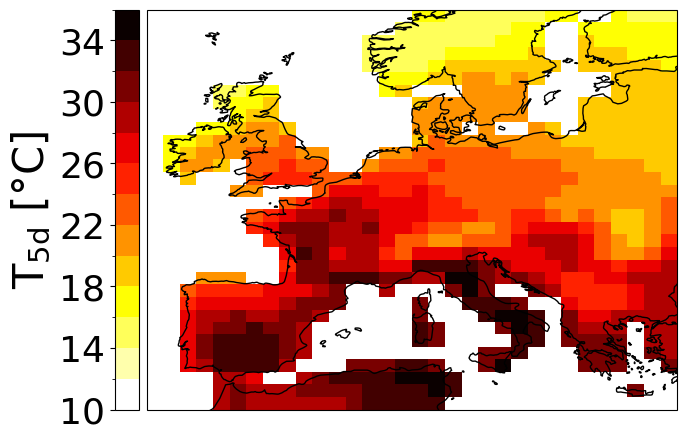

In [3]:
# factual

trefht_hw = fact_dae_mean.TREFHT.sel(time="2003-08-11")

fig = plt.figure(figsize=(8,5))
ax  = fig.add_axes([0.18, 0.1, 0.77, 0.8], projection=ccrs.PlateCarree())
cax = fig.add_axes([0.14, 0.1, 0.02, 0.8])  # same height as map

vmin = 10
vmax = 36
no_levels=14
levels = np.linspace(vmin,vmax,no_levels)

trefht_hw.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    cmap=  "hot_r", #"coolwarm",
    levels=levels,
    cbar_ax=cax,
    cbar_kwargs={"label": "T-Anomaly [°C]"}
)

cax.yaxis.set_label_position("left")
cax.yaxis.tick_left()

cbar = cax
cbar_width = 0.03
cbar_gap = 0.01
cbar_tick_label_size = 26
cbar.set_ylabel(r"$\mathrm{T_{5d}}$ [°C]", fontsize=30)
#cbar.set_ylim(20, 36)
cax.tick_params(axis="y", labelsize=cbar_tick_label_size)
#cbar.set_ticks(np.linspace(vmin,vmax,11))
ax_pos = ax.get_position()
cax.set_position([ax_pos.x0 - cbar_gap - cbar_width, ax_pos.y0, cbar_width, ax_pos.height])
ax.coastlines()
ax.set_title("")
#plt.savefig("CI_talk/intro_fact_temperature_map.pdf", bbox_inches='tight')
plt.show()

### ERA5 bias

In [4]:
########################################
### This is inherent standardisation ###
########################################

# factual
#dae_ensemble_fact = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/ERA5_inherent_ensemble_after_50_epochs/ETH_gen_dpa_ens_50_dataset_restored.nc"
#dae_eth_fact_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_fact)
#dae_eth_fact = xr.open_dataset(dae_eth_fact_path).TREFHT

# counterfactual
#dae_ensemble_cf = "_devicecuda100_6_100_100_1001_20_2_50_encoderislearnable_lambda0.5_alpha1.5_bs128_bnisFalse_lr0.0001_pene0/dae_ensemble_after_50_epochs/ERA5_inherent_ensemble_after_50_epochs/ETH_cf_gen_dpa_ens_50_dataset_restored.nc"
#dae_eth_cf_path = os.path.join(settings['paths']['output_dir'], dae_ensemble_cf)
#dae_eth_cf = xr.open_dataset(dae_eth_cf_path).TREFHT

#weights = np.cos(np.deg2rad(dae_eth_fact.lat))
#dae_eth_ens_spatial_mean = dae_eth_fact.weighted(weights).mean(dim=("lat","lon"))

#weights = np.cos(np.deg2rad(dae_eth_cf.lat))
#dae_eth_ens_spatial_mean_cf = dae_eth_cf.weighted(weights).mean(dim=("lat","lon"))
########################################
########################################
########################################




def weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))

# truth
x_eth_fact_reduced_mean = weighted_domain_mean(ds_test_eth_fact.TSA, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
x_eth_cf_reduced_mean = weighted_domain_mean(ds_test_eth_cf.TREFHT, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

# DAE
dae_eth_ens_spatial_mean = weighted_domain_mean(dae_eth_fact.TREFHT, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)
dae_eth_ens_spatial_mean_cf = weighted_domain_mean(dae_eth_cf.TREFHT, fr_lat_min, fr_lat_max, fr_lon_min, fr_lon_max)

In [5]:
# Truth
weights = np.cos(np.deg2rad(ds_test_eth_fact.lat))
#x_eth_fact_reduced_mean = ds_test_eth_fact.TSA.weighted(weights).mean(dim=("lat","lon"), skipna=True) # absolute temperatures
#x_eth_fact_reduced_mean = ds_test_eth_fact_pre.TSA.weighted(weights).mean(dim=("lat","lon"), skipna=True) # anomalies
x_eth_fact_reduced_mean_numpy = x_eth_fact_reduced_mean.values

# Counterfactual ERA5 test data
weights = np.cos(np.deg2rad(ds_test_eth_cf.lat))
#x_eth_cf_reduced_mean = ds_test_eth_cf.TREFHT.weighted(weights).mean(dim=("lat","lon"), skipna=True) # absolute temperatures
#x_eth_cf_reduced_mean = ds_test_eth_cf_pre.TREFHT.weighted(weights).mean(dim=("lat","lon"), skipna=True) # anomalies
x_eth_cf_reduced_mean_numpy = x_eth_cf_reduced_mean.values

######################################################
# DAE ensemble spat means

# absolute temps
dpa_eth_fact_ensemble_spat_mean = dae_eth_ens_spatial_mean #dpa_ensemble_fact_raw.TREFHT.mean(dim="lat_x_lon")
dpa_eth_cf_ensemble_spat_mean = dae_eth_ens_spatial_mean_cf #dpa_ensemble_raw_cf.TREFHT.mean(dim="lat_x_lon")

# anomalies
#dae_eth_fact_anoms = xr.open_dataset(dae_eth_fact_path).TREFHT
#weights = np.cos(np.deg2rad(dae_eth_fact_anoms.lat))
#dae_eth_ens_spatial_mean = dae_eth_fact_anoms.weighted(weights).mean(dim=("lat","lon"))
#dpa_eth_fact_ensemble_spat_mean = dae_eth_ens_spatial_mean

#dae_eth_cf_anoms = xr.open_dataset(dae_eth_cf_path).TREFHT
#weights = np.cos(np.deg2rad(dae_eth_cf_anoms.lat))
#dae_eth_ens_spatial_mean_cf = dae_eth_cf_anoms.weighted(weights).mean(dim=("lat","lon"))
#dpa_eth_cf_ensemble_spat_mean = dae_eth_ens_spatial_mean_cf
######################################################

# DAE ensemble mean spat mean
dpa_eth_fact_ensemble_mean_spat_mean = dpa_eth_fact_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean = dpa_eth_cf_ensemble_spat_mean.mean(dim="ensemble_member")
dpa_eth_cf_ensemble_mean_spat_mean


print("ERA5 test shapes:", x_eth_fact_reduced_mean_numpy.shape, x_eth_cf_reduced_mean_numpy.shape)
test_sets = [x_eth_fact_reduced_mean_numpy, x_eth_cf_reduced_mean_numpy]
dpa_spat_means = [dpa_eth_fact_ensemble_spat_mean, dpa_eth_cf_ensemble_spat_mean]
dae_ensemble_means_spat_means = [dpa_eth_fact_ensemble_mean_spat_mean, dpa_eth_cf_ensemble_mean_spat_mean]

ERA5 test shapes: (1596,) (1596,)


/tmp/ipykernel_3187871/2931527252.py:6: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()
/tmp/ipykernel_3187871/2931527252.py:6: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()


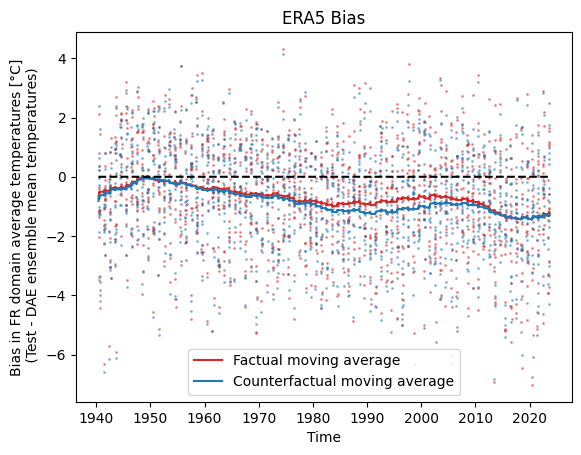

In [6]:
temporal_era5_bias_fact = x_eth_fact_reduced_mean.values - dpa_eth_fact_ensemble_mean_spat_mean.values
temporal_era5_bias_cf = x_eth_cf_reduced_mean - dpa_eth_cf_ensemble_mean_spat_mean.assign_coords(time=x_eth_cf_reduced_mean.time)
temporal_era5_bias_cf

#time = temporal_era5_bias_fact.indexes["time"].to_datetimeindex()
time = x_eth_fact_reduced_mean.indexes["time"].to_datetimeindex()
plt.scatter(time, temporal_era5_bias_fact, color="tab:red", marker='.', alpha=0.4, s=5)
plt.scatter(time, temporal_era5_bias_cf.values, color="tab:blue", marker='.', alpha=0.4, s=5)
#temporal_era5_bias_fact.plot.scatter()

def moving_average_edge(x, window):
    kernel = np.ones(window)
    
    # Convolve data
    smoothed = np.convolve(x, kernel, mode='same')
    
    # Convolve ones to count how many valid points contribute at each position
    counts = np.convolve(np.ones_like(x), kernel, mode='same')
    
    return smoothed / counts

window = 200
smooth_era5_bias_fact = moving_average_edge(temporal_era5_bias_fact, window)
smooth_era5_bias_cf = moving_average_edge(temporal_era5_bias_cf.values, window)
plt.plot(time, smooth_era5_bias_fact, color="tab:red", label="Factual moving average")
plt.plot(time, smooth_era5_bias_cf, color="tab:blue", label="Counterfactual moving average")
plt.plot(time, np.zeros(1596), color='k', linestyle='--')
#plt.ylim(-2.5,2.5)
plt.legend()
plt.xlabel("Time")
plt.ylabel("Bias in FR domain average temperatures [°C]\n (Test - DAE ensemble mean temperatures)")
plt.title("ERA5 Bias")
#plt.savefig("ERA5_2003/FR_time_resolved_bias.pdf")
plt.show()

## Draft

Date: 2003-08-11 00:00:00


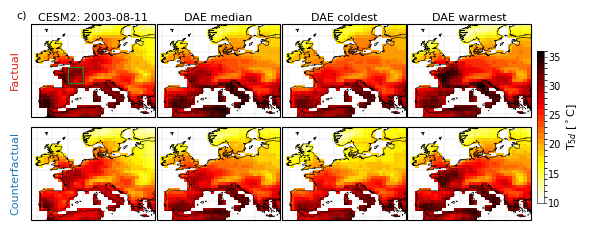

In [7]:
# ---------------------------------------------------------------------
# Domain
# ---------------------------------------------------------------------




# ---------------------------------------------------------------------
# Publication figure settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.42

FONT_SIZE = 8

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": FONT_SIZE,
    "ytick.labelsize": FONT_SIZE,
    "legend.fontsize": FONT_SIZE - 1,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

# ---------------------------------------------------------------------
# Select event
# ---------------------------------------------------------------------
date = 1211  # 2003-08-11
year = 2003
hw_month = "08"
hw_day = "11"

# date = 1506  # 2019-06-27
# year = 2019
# hw_month = "06"
# hw_day = "27"

date_text = f"{year}-{hw_month}-{hw_day}"

print("Date:", ds_test_eth_fact.isel(time=date).time.values)

# ---------------------------------------------------------------------
# Compute ensemble means
# ---------------------------------------------------------------------
fact_dae_mean = fact_dae_mean.TREFHT #.mean(dim="ensemble_member")
cf_dae_mean = cf_dae_mean.TREFHT #.mean(dim="ensemble_member")

# ---------------------------------------------------------------------
# Find coldest / warmest members
# ---------------------------------------------------------------------
imin_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_fact = (
    dae_eth_ens_spatial_mean
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

imin_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmin(dim="ensemble_member")
)

imax_cf = (
    dae_eth_ens_spatial_mean_cf
    .isel(time=date)
    .argmax(dim="ensemble_member")
)

# ---------------------------------------------------------------------
# Fields
# ---------------------------------------------------------------------
fields = [
    # factual
    ds_test_eth_fact.TSA.isel(time=date),
    fact_dae_mean.isel(time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imin_fact, time=date),
    dae_eth_fact.TREFHT.isel(ensemble_member=imax_fact, time=date),

    # counterfactual
    ds_test_eth_cf.TREFHT.isel(time=date),
    cf_dae_mean.isel(time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imin_cf, time=date),
    dae_eth_cf.TREFHT.isel(ensemble_member=imax_cf, time=date),
]

titles = [
    f"CESM2: {date_text}",
    "DAE median",
    "DAE coldest",
    "DAE warmest",
    "",
    "",
    "",
    "",
]

# ---------------------------------------------------------------------
# Plot settings
# ---------------------------------------------------------------------
vmin = 10
vmax = 36

# finer contour levels
levels = np.linspace(vmin, vmax, 27)

# sparse colorbar ticks
cbar_ticks = np.arange(10, 37, 5)

cmap = "hot_r"

# France domain box
box_lat_min = 45
box_lat_max = 50
box_lon_min = 0
box_lon_max = 5

box_lons = [
    box_lon_min,
    box_lon_max,
    box_lon_max,
    box_lon_min,
    box_lon_min,
]

box_lats = [
    box_lat_min,
    box_lat_min,
    box_lat_max,
    box_lat_max,
    box_lat_min,
]

# ---------------------------------------------------------------------
# Create figure
# ---------------------------------------------------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN),
    subplot_kw={"projection": ccrs.PlateCarree()},
    constrained_layout=False,
)

axes = axes.ravel()

# ---------------------------------------------------------------------
# Plot panels
# ---------------------------------------------------------------------
for i, (ax, field, title) in enumerate(zip(axes, fields, titles)):

    # background
    ax.add_feature(
        cfeature.LAND,
        facecolor="0.88",
        edgecolor="none",
        zorder=0,
    )

    ax.coastlines(
        resolution="50m",
        linewidth=0.4,
        zorder=3,
    )

    # temperature field
    pc = field.plot(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap=cmap,
        levels=levels,
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False,
        rasterized=True,
        zorder=2,
    )

    # domain box
    if i == 0:
        ax.plot(
            box_lons,
            box_lats,
            transform=ccrs.PlateCarree(),
            color="forestgreen",
            linewidth=0.8,
            zorder=4,
        )

    # subtle gridlines
    ax.gridlines(
        draw_labels=False,
        linewidth=0.25,
        color="0.5",
        alpha=0.5,
        linestyle="--",
        zorder=1,
    )

    ax.set_title(title, pad=2)

# ---------------------------------------------------------------------
# Row labels
# ---------------------------------------------------------------------
axes[0].text(
    -0.13,
    0.5,
    "Factual",
    transform=axes[0].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:red",
)

axes[4].text(
    -0.13,
    0.5,
    "Counterfactual",
    transform=axes[4].transAxes,
    rotation=90,
    va="center",
    ha="center",
    color="tab:blue",
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
axes[0].text(
    -0.12,
    1.04,
    "c)",
    transform=axes[0].transAxes,
    va="bottom",
    ha="left",
)

# ---------------------------------------------------------------------
# Layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.055,
    right=0.885,
    bottom=0.10,
    top=0.90,
    wspace=0.015,
    hspace=0.04,
)

# ---------------------------------------------------------------------
# Discrete colorbar
# ---------------------------------------------------------------------
cax = fig.add_axes([0.895, 0.18, 0.012, 0.60])

cbar = fig.colorbar(
    pc,
    cax=cax,
    orientation="vertical",
    boundaries=levels,
    ticks=cbar_ticks,
    spacing="proportional",
)

cbar.set_label(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=3,
)

cbar.ax.tick_params(
    labelsize=FONT_SIZE - 1,
    width=0.4,
    length=2,
    pad=1,
)

cbar.outline.set_linewidth(0.4)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(f"Figure06/median_dpa_field_sample_FR_{date_text}.pdf", bbox_inches="tight")

#fig.savefig(
#     f"dpa_field_sample_FR_{date_text}.png",
#     bbox_inches="tight",
#     dpi=600,
#)

plt.show()

/tmp/ipykernel_3187871/874371054.py:327: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword argument.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_3187871/874371054.py:327: RuntimeWarning: Converting a CFTimeIndex with dates from a non-standard calendar, 'noleap', to a pandas.DatetimeIndex, which uses dates from the standard calendar.  This may lead to subtle errors in operations that depend on the length of time between dates.
  time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
/tmp/ipykernel_3187871/874371054.py:328: FutureWarning: In a future version of xarray to_datetimeindex will default to returning a 'us'-resolution DatetimeIndex instead of a 'ns'-resolution DatetimeIndex. This warning can be silenced by explicitly passing the `time_unit` keyword ar

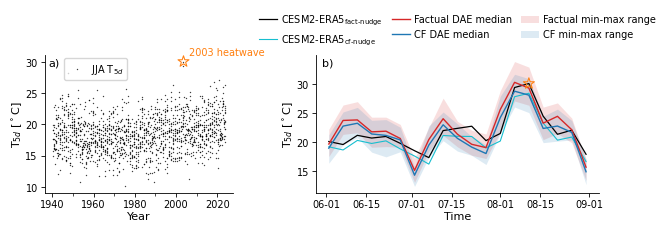

{'true_cf': <xarray.DataArray 'TREFHT' (time: 1596)> Size: 13kB
 array([14.7151219 , 19.03323178, 17.74915396, ..., 24.365289  ,
        20.79549596, 16.61493775], shape=(1596,))
 Coordinates:
   * time     (time) object 13kB 1940-06-02 00:00:00 ... 2023-08-31 00:00:00,
 'true_fact': <xarray.DataArray 'TSA' (time: 1596)> Size: 13kB
 array([14.87709699, 19.16120568, 17.72941678, ..., 26.35042079,
        22.53985248, 18.17260956], shape=(1596,))
 Coordinates:
   * time     (time) object 13kB 1940-06-02 00:00:00 ... 2023-08-31 00:00:00,
 'dpa_cf_mean': <xarray.DataArray 'TREFHT' (time: 1596)> Size: 13kB
 array([18.16467624, 20.69480081, 18.21759654, ..., 27.37986939,
        19.01149477, 17.31576866], shape=(1596,))
 Coordinates:
   * time     (time) object 13kB 1940-06-02 11:30:00 ... 2023-08-31 11:30:00,
 'dpa_fact_mean': <xarray.DataArray 'TREFHT' (time: 1596)> Size: 13kB
 array([18.14289745, 21.41745575, 18.40004396, ..., 29.0840007 ,
        20.89319138, 18.70647658], shape=(1596,))

In [8]:
# using median of ensemble of regional mean values
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4
FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3

FONT_SIZE = 8
SMALL_FONT_SIZE = 7

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": SMALL_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------------
def weighted_domain_mean(da, lat_min, lat_max, lon_min, lon_max):
    """Latitude-weighted spatial mean over a rectangular domain."""
    da_domain = da.sel(
        lat=slice(lat_min, lat_max),
        lon=slice(lon_min, lon_max),
    )

    weights = np.cos(np.deg2rad(da_domain["lat"]))
    weights = xr.DataArray(
        weights,
        coords={"lat": da_domain["lat"]},
        dims=["lat"],
    )

    return da_domain.weighted(weights).mean(dim=("lat", "lon"))


def prepare_dpa_time_series(
    true_cf,
    dpa_ens_cf,
    dpa_ens_mean_cf,
    true_fact,
    dpa_ens_fact,
    dpa_ens_mean_fact,
    lat_min,
    lat_max,
    lon_min,
    lon_max,
    n_stds=2,
):
    if isinstance(dpa_ens_cf, xr.Dataset):
        dpa_ens_cf = dpa_ens_cf.TREFHT

    if isinstance(dpa_ens_fact, xr.Dataset):
        dpa_ens_fact = dpa_ens_fact.TREFHT

    true_cf_mean = weighted_domain_mean(
        true_cf, lat_min, lat_max, lon_min, lon_max
    )

    true_fact_mean = weighted_domain_mean(
        true_fact, lat_min, lat_max, lon_min, lon_max
    )

    dpa_cf_mean_pre = weighted_domain_mean(
        dpa_ens_cf, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_cf, lat_min, lat_max, lon_min, lon_max
    )

    dpa_fact_mean_pre = weighted_domain_mean(
        dpa_ens_fact, lat_min, lat_max, lon_min, lon_max
        #dpa_ens_mean_fact, lat_min, lat_max, lon_min, lon_max
    )

    # compute medians of DAE regional means ensemble 
    dpa_cf_mean = dpa_cf_mean_pre.median(dim="ensemble_member")
    dpa_fact_mean = dpa_fact_mean_pre.median(dim="ensemble_member")

    # envelopes
    # quantiles
    #fact_lower = dpa_fact_mean_pre.quantile(0.025, dim="ensemble_member")
    #fact_upper = dpa_fact_mean_pre.quantile(0.975, dim="ensemble_member")

    #cf_lower = dpa_cf_mean_pre.quantile(0.025, dim="ensemble_member")
    #cf_upper = dpa_cf_mean_pre.quantile(0.975, dim="ensemble_member")

    # min/max
    fact_lower = dpa_fact_mean_pre.min(dim="ensemble_member")
    fact_upper = dpa_fact_mean_pre.max(dim="ensemble_member")
    
    cf_lower = dpa_cf_mean_pre.min(dim="ensemble_member")
    cf_upper = dpa_cf_mean_pre.max(dim="ensemble_member")

    return {
        "true_cf": true_cf_mean,
        "true_fact": true_fact_mean,
        "dpa_cf_mean": dpa_cf_mean,
        "dpa_fact_mean": dpa_fact_mean,
        #"cf_lower": dpa_cf_mean - n_stds * dpa_cf_std,
        #"cf_upper": dpa_cf_mean + n_stds * dpa_cf_std,
        "cf_lower": cf_lower,
        "cf_upper": cf_upper,
        "fact_lower": fact_lower,
        "fact_upper": fact_upper,
        "n_stds": n_stds,
    }


def _to_datetime_index(da):
    return da.indexes["time"].to_datetimeindex()


def _select_year(da, plot_year):
    if plot_year is None:
        return da

    try:
        return da.sel(time=str(plot_year))
    except Exception:
        time = _to_datetime_index(da)
        return da.isel(time=time.year == int(plot_year))


def plot_dpa_time_series_on_ax(
    ax,
    ts,
    plot_year=None,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
):
    true_cf = _select_year(ts["true_cf"], plot_year)
    true_fact = _select_year(ts["true_fact"], plot_year)
    dpa_cf_mean = _select_year(ts["dpa_cf_mean"], plot_year)
    dpa_fact_mean = _select_year(ts["dpa_fact_mean"], plot_year)
    cf_lower = _select_year(ts["cf_lower"], plot_year)
    cf_upper = _select_year(ts["cf_upper"], plot_year)
    fact_lower = _select_year(ts["fact_lower"], plot_year)
    fact_upper = _select_year(ts["fact_upper"], plot_year)

    time = _to_datetime_index(true_fact)



    

    ax.plot(
        time,
        true_fact.values,
        color="black",
        linewidth=0.9,
        linestyle="-",
        label=r"$\mathrm{\mathrm{CESM2\text{-}ERA5_{fact\text{-}nudge}}}$",
    )

    ax.plot(
        time,
        true_cf.values,
        color="tab:cyan",
        linewidth=0.8,
        linestyle="-",
        label=r"$\mathrm{\mathrm{CESM2\text{-}ERA5_{cf\text{-}nudge}}}$",
    )
    
    ax.plot(
        time,
        dpa_fact_mean.values,
        color="tab:red",
        linewidth=1.0,
        label="Factual DAE median",
    )
    
    ax.plot(
        time,
        dpa_cf_mean.values,
        color="tab:blue",
        linewidth=1.0,
        label="CF DAE median",
    )

    

    ax.fill_between(
        time,
        fact_lower.values,
        fact_upper.values,
        color="tab:red",
        alpha=0.15,
        linewidth=0,
        label="Factual min-max range"
        #label=rf"Factual DAE $\pm {ts['n_stds']}\sigma$",
    )
    
    ax.fill_between(
        time,
        cf_lower.values,
        cf_upper.values,
        color="tab:blue",
        alpha=0.15,
        linewidth=0,
        label="CF min-max range"
        #label=rf"CF DAE $\pm {ts['n_stds']}\sigma$",
    )

    


    

    time_2003 = true_fact.sel(time="2003-08-11").indexes["time"].to_datetimeindex()
    heatwave_value = true_fact.sel(time="2003-08-11").values

    ax.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
    )
    
    ax.set_ylabel(ylabel, labelpad=1)
    ax.set_xlabel("Time", labelpad=1)

    #ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
    #ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))

    # ---------------------------------------------------------------------
    # Date formatting
    # ---------------------------------------------------------------------
    #ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    
    #ax.xaxis.set_minor_locator(mdates.DayLocator(interval=3))

    ax.tick_params(
        axis="both",
        which="major",
        direction="out",
        pad=2,
    )
    ax.tick_params(
    axis="x",
    which="major",
    #rotation=45,
    )

    ax.text(
        0.02,
        0.98,
        panel_label,
        transform=ax.transAxes,
        fontsize=FONT_SIZE,
        #fontweight="bold",
        ha="left",
        va="top",
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    
    # ADD PATCH
    # two-color legend entry
    patch1 = mpatches.Patch(facecolor='tab:red', alpha=0.2, edgecolor='none')
    patch2 = mpatches.Patch(facecolor='tab:blue', alpha=0.2, edgecolor='none')
    
    # existing legend items
    handles, labels = ax.get_legend_handles_labels()
    
    # append tuple of patches
    handles.append((patch1, patch2))
    labels.append("Fact / CF DAE \n min-max range")
    ax.legend(
        #handles=handles,
        #labels=labels,
        #handler_map={tuple: HandlerTuple(ndivide=None)},
        loc="lower center",
        bbox_to_anchor=(0.5, 1.02),
        ncol=3,
        frameon=False,
        handlelength=1.8,
        columnspacing=1.0,
        handletextpad=0.4,
        borderaxespad=0.2,
    )


# ---------------------------------------------------------------------
# FR domain
# --------------------------------------------------------------------fr

# ---------------------------------------------------------------------
# Left-panel data: absolute time series
# ---------------------------------------------------------------------
ds_1300 = ds_test_eth_fact

trefht_1300_abs = ut.get_ger_1d_data(
    ds_1300.TSA,
    lat_min=fr_lat_min,
    lat_max=fr_lat_max,
    lon_min=fr_lon_min,
    lon_max=fr_lon_max,
)

ds_5day_jja_celsius = trefht_1300_abs

time = ds_5day_jja_celsius.indexes["time"].to_datetimeindex()
time_2003 = ds_5day_jja_celsius.sel(time="2003-08-11").indexes["time"].to_datetimeindex()
heatwave_value = ds_5day_jja_celsius.sel(time=date_text).values



# ---------------------------------------------------------------------
# Right-panel data: DAE time series
# ---------------------------------------------------------------------
year_tp = year

ts = prepare_dpa_time_series(
    true_cf=ds_test_eth_cf.TREFHT.isel(time=slice(0, 4769)),
    dpa_ens_cf=dae_eth_cf.isel(time=slice(0, 4769)),
    dpa_ens_mean_cf=cf_dae_mean.isel(time=slice(0, 4769)),

    true_fact=ds_test_eth_fact.TSA.isel(time=slice(0, 4769)),
    dpa_ens_fact=dae_eth_fact.isel(time=slice(0, 4769)),
    dpa_ens_mean_fact=fact_dae_mean.isel(time=slice(0, 4769)),

    lat_min=fr_lat_min,
    lat_max=fr_lat_max,
    lon_min=fr_lon_min,
    lon_max=fr_lon_max,
    n_stds=2,
)

# ---------------------------------------------------------------------
# Combined figure: 153 mm total width, 1/1 width ratio
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.4, 0.6],
    wspace=0.35,
)

ax_left = fig.add_subplot(gs[0, 0])
ax_right = fig.add_subplot(gs[0, 1])

# =====================================================================
# LEFT PANEL: long-term absolute time series
# =====================================================================
ax_left.scatter(
    time,
    ds_5day_jja_celsius.values,
    marker=".",
    s=4,
    color="black",
    alpha=0.75,
    linewidths=0,
    label=r"JJA $\mathrm{T}_{5d}$",
)

ax_left.scatter(
    time_2003,
    heatwave_value,
    marker="*",
    s=70,
    facecolors="none",
    edgecolors="tab:orange",
    linewidth=0.75,
    zorder=5,
)

ax_left.annotate(
    "2003 heatwave",
    xy=(time_2003[0], heatwave_value),
    xytext=(4, 3),
    textcoords="offset points",
    fontsize=SMALL_FONT_SIZE,
    color="tab:orange",
    ha="left",
    va="bottom",
)

ax_left.set_ylabel(r"$\mathrm{T}_{5d}$ [$^\circ$C]", labelpad=1)
ax_left.set_xlabel("Year", labelpad=1)

ax_left.xaxis.set_major_locator(mdates.YearLocator(base=20))
ax_left.xaxis.set_minor_locator(mdates.YearLocator(base=10))
ax_left.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax_left.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax_left.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)

ax_left.legend(
    loc="upper left",
    bbox_to_anchor=(0.10, 0.98),
    frameon=True,
    handletextpad=0.4,
    borderaxespad=0.0,
    labelspacing=0.35,
    fontsize=SMALL_FONT_SIZE,
)

ax_left.text(
    0.02,
    0.98,
    "a)",
    transform=ax_left.transAxes,
    fontsize=FONT_SIZE,
    #fontweight="bold",
    ha="left",
    va="top",
)

# =====================================================================
# RIGHT PANEL: DAE event time series
# =====================================================================
plot_dpa_time_series_on_ax(
    ax_right,
    ts,
    plot_year=year_tp,
    panel_label="b)",
    ylabel=r"$\mathrm{T}_{5d}$ [$^\circ$C]",
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.065,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(
#    f"Figure06/FR_median_combined_time_series_{year_tp}.pdf",
#    bbox_inches="tight",
#    pad_inches=0.01,
#)

plt.show()

ts

## Add risk-based distributions

In [9]:
# Factual ERA5 test data
ds_test_le_fact = ds_test_eth_fact 


# unstack time --> ensemble members
# ds dims: time=476900, lat=32, lon=32
n_ens = 1
n_t = 1596

if ds_test_le_fact.sizes["time"] != n_ens * n_t:
    raise ValueError("time dimension does not match 100 * 4769")

# build ensemble and within-member time-step labels
ens = np.repeat(np.arange(1, n_ens + 1), n_t)
t_in_ens = np.tile(np.arange(n_t), n_ens)


ds_test_le_fact_unstacked = ds_test_le_fact 

# factual distribution (1988-2018)
trefht_le_fact_2011_61 = ds_test_le_fact_unstacked.TSA.sel(time=slice("1988", "2018"))

trefht_le_fact_0627 = trefht_le_fact_2011_61.sel(
    time=(trefht_le_fact_2011_61.time.dt.month == 8) & (trefht_le_fact_2011_61.time.dt.day == 11)
)
trefht_le_fact_0627

# counterfactual distribution (1940-1970)
trefht_le_fact_1850_1900 = ds_test_le_fact_unstacked.TSA.sel(time=slice("1940", "1970"))

trefht_le_cf_0627 = trefht_le_fact_1850_1900.sel(
    time=(trefht_le_fact_1850_1900.time.dt.month == 8) & (trefht_le_fact_1850_1900.time.dt.day == 11)
)
trefht_le_fact_0627

<xarray.DataArray 'TSA' (time: 31, lat: 32, lon: 32)> Size: 127kB
array([[[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 28.816772,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 14.13855 , 14.62088 ,
         15.058868],
        [      nan,       nan,       nan, ..., 12.856964, 13.685425,
         14.358398],
        [      nan,       nan,       nan, ..., 12.057922, 12.546875,
         13.190369]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 29.26294 ,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
...
        [      nan,       nan,       nan, ..., 19.18457 , 19.457123,
         19.588928],
        [      nan,       nan,       nan, ..., 17.65326 , 18.205994,
         18.460266],
        [      nan,       nan,       nan, ..., 16.861328, 17.148499,
         17.387115]],

       [[      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        [      nan,       nan,       nan, ..., 29.693817,       nan,
               nan],
        [      nan,       nan,       nan, ...,       nan,       nan,
               nan],
        ...,
        [      nan,       nan,       nan, ..., 20.32608 , 21.019684,
         21.630035],
        [      nan,       nan,       nan, ..., 19.458435, 20.240845,
         20.77185 ],
        [      nan,       nan,       nan, ..., 18.886658, 19.039581,
         19.38086 ]]], shape=(31, 32, 32), dtype=float32)
Coordinates:
  * time     (time) object 248B 1988-08-11 00:00:00 ... 2018-08-11 00:00:00
  * lat      (lat) float64 256B 34.4 35.34 36.28 37.23 ... 61.73 62.67 63.61
  * lon      (lon) float64 256B -11.25 -10.0 -8.75 -7.5 ... 25.0 26.25 27.5

In [10]:
# compute domain averages
trefht_le_fact_0627_ger = ut.get_ger_1d_data(trefht_le_fact_0627, 
                                     lat_min = fr_lat_min,
                                     lat_max = fr_lat_max,
                                     lon_min = fr_lon_min,
                                     lon_max = fr_lon_max
                                            )
trefht_le_cf_0627_ger = ut.get_ger_1d_data(trefht_le_cf_0627,
                                     lat_min = fr_lat_min,
                                     lat_max = fr_lat_max,
                                     lon_min = fr_lon_min,
                                     lon_max = fr_lon_max
                                          )

trefht_le_fact_0627_ger
trefht_le_cf_0627_ger

<xarray.DataArray 'TSA' (time: 31)> Size: 248B
array([19.56110133, 17.35394231, 18.6035395 , 17.72391923, 22.96856052,
       17.99579192, 19.52143837, 22.0039014 , 17.48939157, 19.39497609,
       20.84548245, 16.87563192, 20.99236573, 23.26258241, 16.75424471,
       16.69341875, 19.82386667, 19.4537859 , 19.8284878 , 20.41957905,
       17.40465012, 19.26975829, 18.25656993, 17.12334831, 16.37479074,
       19.32024123, 20.90357055, 18.61257228, 18.47126906, 22.80588635,
       17.66773918])
Coordinates:
  * time     (time) object 248B 1940-08-11 00:00:00 ... 1970-08-11 00:00:00

In [11]:
# define functions
from matplotlib.patches import Patch

#importlib.reload(evaluation)

# ---------------------------------------------------------------------
# Region settings
# ---------------------------------------------------------------------
LAT_MIN, LAT_MAX = fr_lat_min, fr_lat_max
LON_MIN, LON_MAX = fr_lon_min, fr_lon_max
print(LAT_MIN, LAT_MAX, LON_MIN, LON_MAX)

TIME_SLICE = slice(0, 4769)
YEAR = year #1506
DATE = date_text #"2019-06-27"

N_BOOT = 2000
ALPHA = 0.05
TEXT_FS = 8#text_fs  # assumes text_fs already exists in your notebook/script

# ---------------------------------------------------------------------
# Helper functions
# ---------------------------------------------------------------------
def area_weighted_mean(data, lat_min, lat_max, lon_min, lon_max, time=None):
    """Compute cosine-latitude weighted regional mean."""
    regional = data.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))
    if time is not None:
        regional = regional.sel(time=time)

    weights = np.cos(np.deg2rad(regional["lat"]))
    weights_da = xr.DataArray(weights, coords={"lat": regional["lat"]}, dims=["lat"])

    return regional.weighted(weights_da).mean(dim=("lat", "lon"))


def bootstrap_median(values, n_boot=1000, alpha=0.05, rng=None):
    """
    Bootstrap the sample median and return:
    - median of bootstrap medians
    - lower / upper CI of bootstrap medians
    - all bootstrap medians
    """
    values = np.asarray(values).ravel()
    n = values.size

    if rng is None:
        rng = np.random.default_rng()

    boot_medians = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        sample = rng.choice(values, size=n, replace=True)
        boot_medians[i] = np.median(sample)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    median_of_medians = np.median(boot_medians)
    ci_low = np.percentile(boot_medians, lower_q)
    ci_high = np.percentile(boot_medians, upper_q)

    return median_of_medians, ci_low, ci_high, boot_medians


def bootstrap_kde_ci(samples, x_grid, n_boot=1000, alpha=0.05, rng=None, bw_method=None):
    """
    Bootstrap pointwise confidence intervals for a Gaussian KDE.

    Returns
    -------
    kde_ref : ndarray
        KDE estimated from the original sample.
    kde_low : ndarray
        Lower pointwise confidence bound.
    kde_high : ndarray
        Upper pointwise confidence bound.
    kde_boot : ndarray
        All bootstrap KDE evaluations.
    """
    samples = np.asarray(samples).ravel()
    n = samples.size

    if rng is None:
        rng = np.random.default_rng()

    kde_boot = np.empty((n_boot, len(x_grid)), dtype=float)

    for i in range(n_boot):
        resample = rng.choice(samples, size=n, replace=True)
        kde = gaussian_kde(resample, bw_method=bw_method)
        kde_boot[i] = kde(x_grid)

    kde_ref = gaussian_kde(samples, bw_method=bw_method)(x_grid)

    lower_q = 100 * (alpha / 2)
    upper_q = 100 * (1 - alpha / 2)

    kde_low = np.percentile(kde_boot, lower_q, axis=0)
    kde_high = np.percentile(kde_boot, upper_q, axis=0)

    return kde_ref, kde_low, kde_high, kde_boot


# ---------------------------------------------------------------------
# Load data
# ---------------------------------------------------------------------
cf_truth_all = ds_test_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_all = dae_eth_cf.isel(time=TIME_SLICE).TREFHT
cf_ensemble_mean_all = cf_dae_mean.isel(time=TIME_SLICE)

fact_truth_all = ds_test_eth_fact.isel(time=TIME_SLICE).TSA
fact_ensemble_all = dae_eth_fact.isel(time=TIME_SLICE)
fact_ensemble_mean_all = fact_dae_mean.isel(time=TIME_SLICE)

#2028
cf_2028_ensemble_all = dae_eth_cf_2028.isel(time=TIME_SLICE).TREFHT
cf_2028_ensemble_mean_all = cf_2028_dae_mean.isel(time=TIME_SLICE)

#2053
cf_2053_ensemble_all = dae_eth_cf_2053.isel(time=TIME_SLICE).TREFHT
cf_2053_ensemble_mean_all = cf_2053_dae_mean.isel(time=TIME_SLICE)



# ---------------------------------------------------------------------
# Regional averages on selected date
# ---------------------------------------------------------------------
# Counterfactual
cf_single_ensemble_mean_ger = area_weighted_mean(
    cf_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_ensemble_members_ger = area_weighted_mean(
    cf_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_truth_ger = area_weighted_mean(
    cf_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# Factual
fact_single_ensemble_mean_ger = area_weighted_mean(
    fact_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_ensemble_members_ger = area_weighted_mean(
    fact_ensemble_all.TREFHT, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
fact_truth_ger = area_weighted_mean(
    fact_truth_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# 2028 CF
cf_2028_single_ensemble_mean_ger = area_weighted_mean(
    cf_2028_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_2028_ensemble_members_ger = area_weighted_mean(
    cf_2028_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

# 2053 CF
cf_2053_single_ensemble_mean_ger = area_weighted_mean(
    cf_2053_ensemble_mean_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)
cf_2053_ensemble_members_ger = area_weighted_mean(
    cf_2053_ensemble_all, LAT_MIN, LAT_MAX, LON_MIN, LON_MAX, time=DATE
)

cf_2053_values = cf_2053_ensemble_members_ger.values.ravel()
cf_2028_values = cf_2028_ensemble_members_ger.values.ravel()
cf_values = cf_ensemble_members_ger.values.ravel()
fact_values = fact_ensemble_members_ger.values.ravel()

# ---------------------------------------------------------------------
# Bootstrap medians
# ---------------------------------------------------------------------
cf_boot_median, cf_median_ci_low, cf_median_ci_high, cf_boot_medians = bootstrap_median(
    cf_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

fact_boot_median, fact_median_ci_low, fact_median_ci_high, fact_boot_medians = bootstrap_median(
    fact_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(43),
)

# 2028
cf_2028_boot_median, cf_2028_median_ci_low, cf_2028_median_ci_high, cf_2028_boot_medians = bootstrap_median(
    cf_2028_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

# 2053
cf_2053_boot_median, cf_2053_median_ci_low, cf_2053_median_ci_high, cf_2053_boot_medians = bootstrap_median(
    cf_2053_values,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(42),
)

# ---------------------------------------------------------------------
# KDE + bootstrap KDE confidence intervals
# ---------------------------------------------------------------------
bins = np.linspace(
    min(cf_values.min(), fact_values.min(), cf_2028_values.min(), cf_2053_values.min()),
    max(cf_values.max(), fact_values.max(), cf_2028_values.max(), cf_2053_values.max()),
    30,
)
x = np.linspace(bins[0], bins[-1], 500)

# Optional fixed bandwidth for more stable bootstrap-KDE CIs
cf_bw = gaussian_kde(cf_values).factor
fact_bw = gaussian_kde(fact_values).factor
cf_2028_bw = gaussian_kde(cf_2028_values).factor
cf_2053_bw = gaussian_kde(cf_2053_values).factor


cf_kde, cf_kde_low, cf_kde_high, _ = bootstrap_kde_ci(
    cf_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

fact_kde, fact_kde_low, fact_kde_high, _ = bootstrap_kde_ci(
    fact_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(45),
    bw_method=fact_bw,
)

# 2028
cf_2028_kde, cf_2028_kde_low, cf_2028_kde_high, _ = bootstrap_kde_ci(
    cf_2028_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)

# 2053
cf_2053_kde, cf_2053_kde_low, cf_2053_kde_high, _ = bootstrap_kde_ci(
    cf_2053_values,
    x_grid=x,
    n_boot=N_BOOT,
    alpha=ALPHA,
    rng=np.random.default_rng(44),
    bw_method=cf_bw,
)



from matplotlib.patches import Rectangle
from matplotlib.legend_handler import HandlerBase

class HandlerTwoColorPatch(HandlerBase):
    def create_artists(self, legend, orig_handle,
                       xdescent, ydescent, width, height, fontsize, trans):

        r1 = Rectangle(
            (xdescent, ydescent), width/2, height,
            facecolor="tab:blue", alpha=0.15, transform=trans
        )
        r2 = Rectangle(
            (xdescent + width/2, ydescent), width/2, height,
            facecolor="tab:red", alpha=0.15, transform=trans
        )

        return [r1, r2]

# ci_handle = object()


45 50 0 5


FACT median: 29.28110307156331
CF 2028 median: 30.32320765941044
CF 2053 median: 32.077219658330506
CF baseline median: 28.056525664361217
Median intensity change: 1.24535533492028


/tmp/ipykernel_3187871/2863127450.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  t_obs = float(fact_truth_ger.values)


Observed threshold: 30.043 °C
Median PR: 5.667
IQR: [4.200, 8.000]
95% CI: [2.625, 25.000]
Fact PR boot: 5.666666666666667
2028 PR boot: 2.103448275862069
2053 PR boot: 3.1538461538461537


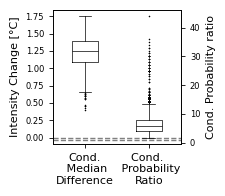

In [12]:
# ---------------------------------------------------------------------
# Bootstrap probability ratios for P(T >= observed)
# and plot as a box plot
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt


def bootstrap_probability_ratio(
    fact_values,
    cf_values,
    threshold,
    n_boot=2000,
    rng=None,
    correction=0.0,
):
    """
    Bootstrap the probability ratio

        PR = P_fact(T >= threshold) / P_cf(T >= threshold)

    using ensemble-member resampling with replacement.

    Parameters
    ----------
    fact_values : array-like
        Factual ensemble values for one day / region.
    cf_values : array-like
        Counterfactual ensemble values for one day / region.
    threshold : float
        Observed threshold temperature.
    n_boot : int
        Number of bootstrap resamples.
    rng : np.random.Generator or None
        Random number generator.
    correction : float
        Continuity correction to avoid division by zero when the
        counterfactual exceedance count is 0. Applied to both numerator
        and denominator counts as:
            p = (k + correction) / (n + 2 * correction)

    Returns
    -------
    pr_boot : ndarray
        Bootstrapped probability ratios.
    p_fact_boot : ndarray
        Bootstrapped factual exceedance probabilities.
    p_cf_boot : ndarray
        Bootstrapped counterfactual exceedance probabilities.
    """
    fact_values = np.asarray(fact_values).ravel()
    cf_values = np.asarray(cf_values).ravel()

    n_fact = fact_values.size
    n_cf = cf_values.size

    if rng is None:
        rng = np.random.default_rng()

    pr_boot = np.empty(n_boot, dtype=float)
    p_fact_boot = np.empty(n_boot, dtype=float)
    p_cf_boot = np.empty(n_boot, dtype=float)

    for i in range(n_boot):
        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        k_fact = np.sum(fact_sample >= threshold)
        k_cf = np.sum(cf_sample >= threshold)
        #print("k_cf:", k_cf)

        # Continuity-corrected exceedance probabilities
        p_fact = (k_fact + correction) / (n_fact + 2 * correction)
        p_cf = (k_cf + correction) / (n_cf + 2 * correction)

        p_fact_boot[i] = p_fact
        p_cf_boot[i] = p_cf

        if p_cf != 0:
            pr_boot[i] = p_fact / p_cf
        else:
            pr_boot[i] = 10e8

    return pr_boot, p_fact_boot, p_cf_boot


# ---------------------------------------------------------------------
# Use existing values from your earlier code
# ---------------------------------------------------------------------
# Assumes these already exist:
#   fact_values
#   cf_values
#   fact_truth_ger
#   TEXT_FS

boot_median_diff = fact_boot_medians - cf_boot_medians
boot_median_diff_2028 = cf_2028_boot_medians - fact_boot_medians
boot_median_diff_2053 = cf_2053_boot_medians - fact_boot_medians

print("FACT median:", np.median(fact_boot_medians))
print("CF 2028 median:", np.median(cf_2028_boot_medians))
print("CF 2053 median:", np.median(cf_2053_boot_medians))
print("CF baseline median:", np.median(cf_boot_medians))

print("Median intensity change:", np.percentile(boot_median_diff, 50))


t_obs = float(fact_truth_ger.values)

############################
### THIS CHANGED TO 2028 ###
############################

pr_boot, p_fact_boot, p_cf_boot = bootstrap_probability_ratio(
    fact_values=fact_values,
    cf_values=cf_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    #correction=0.5,
)
pr_boot_2028, p_fact_boot_2028, p_cf_boot_2028 = bootstrap_probability_ratio(
    fact_values=cf_2028_values,
    cf_values=fact_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    #correction=0.5,
)

pr_boot_2053, p_fact_boot_2053, p_cf_boot_2053 = bootstrap_probability_ratio(
    fact_values=cf_2053_values,
    cf_values=fact_values,
    threshold=t_obs,
    n_boot=2000,
    rng=np.random.default_rng(123),
    #correction=0.5,
)



# Summary stats
pr_median = np.nanmedian(pr_boot)
pr_q025 = np.percentile(pr_boot, 2.5)
pr_q25 = np.percentile(pr_boot, 25)
pr_q75 = np.percentile(pr_boot, 75)
pr_q975 = np.percentile(pr_boot, 97.5)

print(f"Observed threshold: {t_obs:.3f} °C")
print(f"Median PR: {pr_median:.3f}")
print(f"IQR: [{pr_q25:.3f}, {pr_q75:.3f}]")
print(f"95% CI: [{pr_q025:.3f}, {pr_q975:.3f}]")

print("Fact PR boot:", np.nanmedian(pr_boot))
print("2028 PR boot:", np.nanmedian(pr_boot_2028))
print("2053 PR boot:", np.nanmedian(pr_boot_2053))


# ---------------------------------------------------------------------
# Box plot
# ---------------------------------------------------------------------


fig, ax1 = plt.subplots(figsize=(2.3, 2.0))

# -------------------------------------------------
# Left axis: median difference
# -------------------------------------------------
lw=0.5

box1 = ax1.boxplot(
    boot_median_diff,
    positions=[1],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax1.axhline(0, color="gray", linestyle="--", linewidth=1)

ax1.set_ylabel(
    "Intensity Change [°C]", #\n(Factual − Counterfactual)",
    fontsize=8
)

ax1.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# Right axis: probability ratio
# -------------------------------------------------
ax2 = ax1.twinx()

box2 = ax2.boxplot(
    pr_boot[pr_boot != 10e8],
    positions=[2],
    widths=0.4,
    vert=True,
    showfliers=True,
    flierprops={
        "marker": "x",
        "markersize": lw,
        "markerfacecolor": "k",
        "markeredgecolor": "k",
        "alpha": 1.0},
    patch_artist=False,
    medianprops={"linewidth": lw, "color": "black"},
    boxprops={"linewidth": lw},
    whiskerprops={"linewidth": lw},
    capprops={"linewidth": lw},
)

ax2.axhline(1, color="gray", linestyle="--", linewidth=1)

ax2.set_ylabel(
    "Cond. Probability ratio", #\n$P_{fact}(T ≥ T_{obs}) / P_{cf}(T ≥ T_{obs})$",
    fontsize=8
)
#ax2.set_ylim(0,30)

ax2.tick_params(axis="y", labelsize=6)


# -------------------------------------------------
# X axis formatting
# -------------------------------------------------
ax1.set_xticks([1, 2])
ax1.set_xticklabels(
    ["Cond.\n Median\nDifference", "Cond. \n Probability\nRatio"],
    fontsize=8
)

#ax1.text(0.05, 0.93, "(d)", transform=ax1.transAxes, fontsize=text_fs)

plt.tight_layout()
#plt.savefig("poster_hw2003_FR_boxplot.pdf")
plt.show()

def bootstrap_intensity_shift(fact_values, cf_values, t_obs, n_boot=2000, rng=None):

    fact_values = np.asarray(fact_values)
    cf_values = np.asarray(cf_values)

    n_fact = len(fact_values)
    n_cf = len(cf_values)

    if rng is None:
        rng = np.random.default_rng()

    delta = np.empty(n_boot)

    for i in range(n_boot):

        fact_sample = rng.choice(fact_values, size=n_fact, replace=True)
        cf_sample = rng.choice(cf_values, size=n_cf, replace=True)

        p_fact = np.mean(fact_sample >= t_obs)
        t_cf_equiv = np.quantile(cf_sample, 1 - p_fact)

        delta[i] = t_obs - t_cf_equiv

    return delta


delta_boot = bootstrap_intensity_shift(
    fact_values,
    cf_values,
    t_obs,
    n_boot=2000,
    rng=np.random.default_rng(0)
)



## Plot timeseries

Factual risk mean: 20.66113861101746
CF risk mean: 19.15407753686328
risk signal: 1.50706107415418
Factual risk min/max: 17.063205909064386 30.042603208333947
CF risk min/max: 16.374790744221098 23.26258241264646


/tmp/ipykernel_3187871/4040077420.py:448: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(cf_truth_ger.values),
/tmp/ipykernel_3187871/4040077420.py:455: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(fact_truth_ger.values),


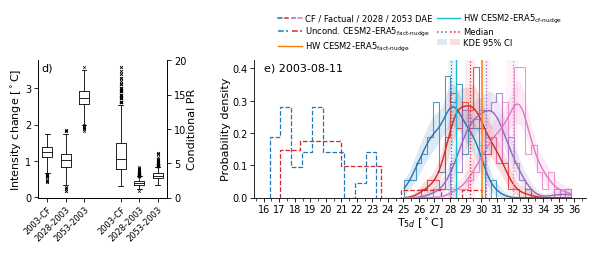

In [13]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple

# ---------------------------------------------------------------------
# Publication-ready settings
# ---------------------------------------------------------------------
FIG_WIDTH_MM = 153
FIG_WIDTH_IN = FIG_WIDTH_MM / 25.4

FIG_HEIGHT_IN = FIG_WIDTH_IN * 0.3

FONT_SIZE = 8
SMALL_FONT_SIZE = 7
TINY_FONT_SIZE = 6

plt.rcParams.update({
    "font.size": FONT_SIZE,
    "axes.labelsize": FONT_SIZE,
    "axes.titlesize": FONT_SIZE,
    "xtick.labelsize": SMALL_FONT_SIZE,
    "ytick.labelsize": SMALL_FONT_SIZE,
    "legend.fontsize": TINY_FONT_SIZE,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.linewidth": 0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.5,
    "ytick.minor.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.8,
    "ytick.minor.size": 1.8,
})

# ---------------------------------------------------------------------
# Figure layout
# ---------------------------------------------------------------------
fig = plt.figure(figsize=(FIG_WIDTH_IN, FIG_HEIGHT_IN))

gs = fig.add_gridspec(
    nrows=1,
    ncols=2,
    width_ratios=[0.28, 0.72],
    wspace=0.38,
)

# =====================================================================
# LEFT PANEL: BOXPLOTS
# =====================================================================
ax1 = fig.add_subplot(gs[0, 0])

LW = 0.6

common_boxprops = {
    "widths": 0.16,
    "vert": True,
    "showfliers": True,
    "patch_artist": False,
    "flierprops": {
        "marker": "x",
        "markersize": 2,
        "markeredgewidth": 0.5,
        "markerfacecolor": "black",
        "markeredgecolor": "black",
        "alpha": 0.9,
    },
    "medianprops": {"linewidth": LW, "color": "black"},
    "boxprops": {"linewidth": LW, "color": "black"},
    "whiskerprops": {"linewidth": LW, "color": "black"},
    "capprops": {"linewidth": LW, "color": "black"},
}

# ---------------------------------------------------------------------
# Alternative styles
# ---------------------------------------------------------------------
common_boxprops_2853 = {
    **common_boxprops,
    "medianprops": {"linewidth": LW, "color": "black", "linestyle": "--"},
    "boxprops": {"linewidth": LW, "color": "black", "linestyle": "--"},
    "whiskerprops": {"linewidth": LW, "color": "black", "linestyle": "--"},
    "capprops": {"linewidth": LW, "color": "black", "linestyle": "--"},
}

common_boxprops_2053 = {
    **common_boxprops,
    "medianprops": {"linewidth": LW, "color": "black", "linestyle": ":"},
    "boxprops": {"linewidth": LW, "color": "black", "linestyle": ":"},
    "whiskerprops": {"linewidth": LW, "color": "black", "linestyle": ":"},
    "capprops": {"linewidth": LW, "color": "black", "linestyle": ":"},
}

# boxplot positions
bp_positions = [0.6, 0.9, 1.2, 1.8, 2.1, 2.4]

# ---------------------------------------------------------------------
# Left axis: intensity change
# ---------------------------------------------------------------------
ax1.boxplot(
    boot_median_diff,
    positions=[bp_positions[0]],
    **common_boxprops,
)

ax1.boxplot(
    boot_median_diff_2028,
    positions=[bp_positions[1]],
    **common_boxprops,
)

ax1.boxplot(
    boot_median_diff_2053,
    positions=[bp_positions[2]],
    **common_boxprops,
)

#ax1.axhline(
#    0,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax1.set_ylabel(
    r"Intensity change [$^\circ$C]",
    labelpad=0.5,
)

ax1.set_xlim(0.45, 2.55)

ax1.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

# ---------------------------------------------------------------------
# Right y-axis: conditional probability ratio
# ---------------------------------------------------------------------
ax2 = ax1.twinx()

ax2.boxplot(
    pr_boot,
    positions=[bp_positions[3]],
    **common_boxprops,
)

ax2.boxplot(
    pr_boot_2028,
    positions=[bp_positions[4]],
    **common_boxprops,
)

ax2.boxplot(
    pr_boot_2053,
    positions=[bp_positions[5]],
    **common_boxprops,
)

#ax2.axhline(
#    1,
#    color="0.5",
#    linestyle="--",
#    linewidth=0.7,
#    zorder=0,
#)

ax2.set_ylabel(
    "Conditional PR",
    labelpad=0.5,
)

ax2.tick_params(
    axis="y",
    which="major",
    direction="out",
    pad=2,
)

ax2.set_ylim(0,20)

# ---------------------------------------------------------------------
# Individual x-axis labels
# ---------------------------------------------------------------------
ax1.set_xticks(bp_positions)
#ax1.set_xticks([0.78, 1.00, 1.22, 1.78, 2.00, 2.22])

ax1.set_xticklabels(
    [
        "2003-CF",
        "2028-2003",
        "2053-2003",
        "2003-CF",
        "2028-2003",
        "2053-2003",
    ],
    fontsize=TINY_FONT_SIZE,
    rotation=45,      # slight rotation
    #ha="right",
    ha="right",
    rotation_mode="anchor",
)

# ---------------------------------------------------------------------
# Panel label
# ---------------------------------------------------------------------
ax1.text(
    0.03,
    0.98,
    "d)",
    transform=ax1.transAxes,
    fontsize=FONT_SIZE,
    ha="left",
    va="top",
)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax1.spines["top"].set_visible(False)
ax2.spines["top"].set_visible(False)

# =====================================================================
# RIGHT PANEL: DISTRIBUTIONS
# =====================================================================
ax = fig.add_subplot(gs[0, 1])

# ---------------------------------------------------------------------
# Conditional histograms
# ---------------------------------------------------------------------
ax.hist(
    cf_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:blue",
)

ax.hist(
    fact_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:red",
)

ax.hist(
    cf_2028_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:purple",
)

ax.hist(
    cf_2053_values,
    bins=bins,
    density=True,
    histtype="step",
    linewidth=0.8,
    alpha=0.75,
    color="tab:pink",
)

# ---------------------------------------------------------------------
# Unconditional histograms
# ---------------------------------------------------------------------
a_risk = trefht_le_cf_0627_ger.values.flatten()
b_risk = trefht_le_fact_0627_ger.values.flatten()

print("Factual risk mean:", np.mean(b_risk))
print("CF risk mean:", np.mean(a_risk))
print("risk signal:", np.mean(b_risk) - np.mean(a_risk))
print("Factual risk min/max:", np.min(b_risk), np.max(b_risk))
print("CF risk min/max:", np.min(a_risk), np.max(a_risk))

ax.hist(
    a_risk,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:blue",
)

ax.hist(
    b_risk,
    density=True,
    histtype="step",
    linewidth=0.9,
    linestyle="--",
    color="tab:red",
)

# ---------------------------------------------------------------------
# KDE confidence intervals
# ---------------------------------------------------------------------
ax.fill_between(
    x,
    cf_kde_low,
    cf_kde_high,
    color="tab:blue",
    alpha=0.15,
    linewidth=0,
)

ax.fill_between(
    x,
    fact_kde_low,
    fact_kde_high,
    color="tab:red",
    alpha=0.15,
    linewidth=0,
)

ax.fill_between(
    x,
    cf_2028_kde_low,
    cf_2028_kde_high,
    color="tab:purple",
    alpha=0.15,
    linewidth=0,
)

ax.fill_between(
    x,
    cf_2053_kde_low,
    cf_2053_kde_high,
    color="tab:pink",
    alpha=0.15,
    linewidth=0,
)

# ---------------------------------------------------------------------
# KDE lines
# ---------------------------------------------------------------------
ax.plot(
    x,
    cf_kde,
    color="tab:blue",
    linewidth=1.0,
)

ax.plot(
    x,
    fact_kde,
    color="tab:red",
    linewidth=1.0,
)

ax.plot(
    x,
    cf_2028_kde,
    color="tab:purple",
    linewidth=1.0,
)

ax.plot(
    x,
    cf_2053_kde,
    color="tab:pink",
    linewidth=1.0,
)

# ---------------------------------------------------------------------
# Median lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_boot_median),
    color="tab:blue",
    linestyle=":",
    linewidth=0.9,
)

ax.axvline(
    float(fact_boot_median),
    color="tab:red",
    linestyle=":",
    linewidth=0.9,
)

ax.axvline(
    float(cf_2028_boot_median),
    color="tab:purple",
    linestyle=":",
    linewidth=0.9,
)

ax.axvline(
    float(cf_2053_boot_median),
    color="tab:pink",
    linestyle=":",
    linewidth=0.9,
)

# ---------------------------------------------------------------------
# Median confidence intervals
# ---------------------------------------------------------------------
ax.axvspan(
    cf_median_ci_low,
    cf_median_ci_high,
    color="tab:blue",
    alpha=0.08,
    linewidth=0,
)

ax.axvspan(
    fact_median_ci_low,
    fact_median_ci_high,
    color="tab:red",
    alpha=0.08,
    linewidth=0,
)

ax.axvspan(
    cf_2028_median_ci_low,
    cf_2028_median_ci_high,
    color="tab:purple",
    alpha=0.08,
    linewidth=0,
)

ax.axvspan(
    cf_2053_median_ci_low,
    cf_2053_median_ci_high,
    color="tab:pink",
    alpha=0.08,
    linewidth=0,
)

# ---------------------------------------------------------------------
# Truth lines
# ---------------------------------------------------------------------
ax.axvline(
    float(cf_truth_ger.values),
    color="tab:cyan",
    linestyle="-",
    linewidth=0.9,
)

ax.axvline(
    float(fact_truth_ger.values),
    color="tab:orange",
    linestyle="-",
    linewidth=1.1,
)

# ---------------------------------------------------------------------
# Labels
# ---------------------------------------------------------------------
ax.set_xlabel(
    r"$\mathrm{T}_{5d}$ [$^\circ$C]",
    labelpad=0.5,
)

ax.set_ylabel(
    "Probability density",
    labelpad=1,
)

# ---------------------------------------------------------------------
# Ticks
# ---------------------------------------------------------------------
ax.xaxis.set_major_locator(MultipleLocator(1.0))
ax.xaxis.set_minor_locator(MultipleLocator(0.5))

ax.tick_params(
    axis="both",
    which="major",
    direction="out",
    pad=2,
)

ax.tick_params(
    axis="x",
    which="minor",
    direction="out",
)

# ---------------------------------------------------------------------
# Panel and date labels
# ---------------------------------------------------------------------
ax.text(
    0.03,
    0.98,
    f"e) {DATE}",
    transform=ax.transAxes,
    fontsize=FONT_SIZE,
    ha="left",
    va="top",
)

#ax.text(
#    0.03,
#    0.88,
#    f"{DATE}",
#    transform=ax.transAxes,
#    fontsize=TINY_FONT_SIZE,
#    ha="left",
#    va="top",
#)

# ---------------------------------------------------------------------
# Styling
# ---------------------------------------------------------------------
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

legend_handles = [
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1),
        Line2D([0], [0], color="tab:red", linewidth=1.1),
        Line2D([0], [0], color="tab:purple", linewidth=1.1),
        Line2D([0], [0], color="tab:pink", linewidth=1.1),
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1,linestyle="--"),
        Line2D([0], [0], color="tab:red", linewidth=1.1,linestyle="--"),
    ),
    Line2D(
        [0], [0],
        color="tab:orange",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{fact}}$ on 1997-07-22"
    ),
    Line2D(
        [0], [0],
        color="tab:cyan",
        linestyle="-",
        linewidth=1,
        label=r"$\mathrm{ETH^{1300}_{nudge}}$ on 1997-07-22"
    ),
    (
        Line2D([0], [0], color="tab:blue", linewidth=1.1, linestyle=":"),
        Line2D([0], [0], color="tab:red", linewidth=1.1, linestyle=":"),
    ),
    (
        Patch(facecolor="tab:blue",alpha=0.15, edgecolor="none"),
        Patch(facecolor="tab:red", alpha=0.15, edgecolor="none"),
    ),
]

legend_labels = [
    "CF / Factual / 2028 / 2053 DAE",
    #" Unconditional" + r"$\mathrm{ETH^{1300}_{fact}}$",
    "Uncond. " + r"$\mathrm{CESM2\text{-}ERA5_{fact\text{-}nudge}}$",
    #r"$\mathrm{ETH^{1300}_{fact}}$ heat event",
    r"HW $\mathrm{CESM2\text{-}ERA5_{fact\text{-}nudge}}$",
    #r"$\mathrm{ETH^{1300}_{nudge}}$ heat event",
    r"HW $\mathrm{CESM2\text{-}ERA5_{cf\text{-}nudge}}$",
    "Median",
    "KDE 95% CI",
]

#ax.legend(
#    handles=legend_handles,
#    labels=legend_labels,
#    handler_map={tuple: HandlerTuple(ndivide=None)},
#    #loc="upper left",
#    loc="upper center",
#    bbox_to_anchor=(0.0, 0.9),
#    frameon=False,
#    handlelength=2.8,
#    handletextpad=0.35,
#    borderaxespad=0.15,
#    labelspacing=0.22,
#    columnspacing=0.55,
#    #ncol=1,
#    ncol=2,
#    fontsize=TINY_FONT_SIZE,
#)

ax.legend(
    handles=legend_handles,
    labels=legend_labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="lower center",
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
    handlelength=2.8,
    handletextpad=0.35,
    borderaxespad=0.15,
    labelspacing=0.22,
    columnspacing=0.55,
    ncol=2,
    fontsize=TINY_FONT_SIZE,
)

# ---------------------------------------------------------------------
# Final layout
# ---------------------------------------------------------------------
fig.subplots_adjust(
    left=0.075,
    right=0.985,
    bottom=0.20,
    top=0.96,
)

# ---------------------------------------------------------------------
# Save
# ---------------------------------------------------------------------
#fig.savefig(
#     "Figure06/FR_combined_attribution_figure_with_future.pdf",
#     bbox_inches="tight",
#     pad_inches=0.01,
#)

plt.show()

In [14]:
print("Heatwave:", fact_truth_ger.values)
print("max T in counterfactual condition. ensemble", cf_values.max())

Heatwave: [30.04260321]
max T in counterfactual condition. ensemble 30.885332989884596


In [15]:
# ---------------------------------------------------------------------
# Print intensity change statistics
# ---------------------------------------------------------------------
print("\n=== Intensity Change ===")

print("CF:")
print("  Median =", np.median(boot_median_diff))
print("  Mean   =", np.mean(boot_median_diff))
print("  95% CI =", np.percentile(boot_median_diff, [2.5, 97.5]))

print("\n2028:")
print("  Median =", np.median(boot_median_diff_2028))
print("  Mean   =", np.mean(boot_median_diff_2028))
print("  95% CI =", np.percentile(boot_median_diff_2028, [2.5, 97.5]))

print("\n2053:")
print("  Median =", np.median(boot_median_diff_2053))
print("  Mean   =", np.mean(boot_median_diff_2053))
print("  95% CI =", np.percentile(boot_median_diff_2053, [2.5, 97.5]))


# ---------------------------------------------------------------------
# Print PR statistics
# ---------------------------------------------------------------------
print("\n=== Conditional Probability Ratio (PR) ===")

print("CF:")
print("  Median =", np.median(pr_boot))
print("  Mean   =", np.mean(pr_boot))
print("  95% CI =", np.percentile(pr_boot, [2.5, 97.5]))

print("\n2028:")
print("  Median =", np.median(pr_boot_2028))
print("  Mean   =", np.mean(pr_boot_2028))
print("  95% CI =", np.percentile(pr_boot_2028, [2.5, 97.5]))

print("\n2053:")
print("  Median =", np.median(pr_boot_2053))
print("  Mean   =", np.mean(pr_boot_2053))
print("  95% CI =", np.percentile(pr_boot_2053, [2.5, 97.5]))


=== Intensity Change ===
CF:
  Median = 1.24535533492028
  Mean   = 1.2351092291547028
  95% CI = [0.73224593 1.62440356]

2028:
  Median = 1.018323777379539
  Mean   = 1.0176480437860946
  95% CI = [0.51778029 1.52318834]

2053:
  Median = 2.737027207218066
  Mean   = 2.736045719545556
  95% CI = [2.1658655  3.22266727]

=== Conditional Probability Ratio (PR) ===
CF:
  Median = 5.666666666666667
  Mean   = 5500006.871481928
  95% CI = [ 2.625 25.   ]

2028:
  Median = 2.103448275862069
  Mean   = 2.1498324165605855
  95% CI = [1.49969512 3.05339912]

2053:
  Median = 3.1538461538461537
  Mean   = 3.234840989333232
  95% CI = [2.37135338 4.52631579]
